# Fake News Detection: LSTM, BERT, and Hybrid Models
This notebook implements three deep learning approaches for fake news detection

# Cell 1: Install Required Packages

In [ ]:
%pip install torch transformers datasets scikit-learn pandas numpy matplotlib seaborn tqdm wordcloud nltk

# Cell 2: Import Libraries and Setup Environment

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import warnings
from tqdm.auto import tqdm
import json
from datetime import datetime
warnings.filterwarnings('ignore')

# Transformers imports
from transformers import (
    AutoTokenizer, AutoModel,
    get_linear_schedule_with_warmup
)

# Scikit-learn imports
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# NLTK imports
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download required NLTK data to prevent FileNotFoundError
nltk.download('punkt')
nltk.download('stopwords')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Using device: cuda
GPU: Tesla T4


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Cell 3: Data Loading and Preprocessing

In [13]:
class TextPreprocessor:
    def __init__(self):
        self.stemmer = PorterStemmer()
        try:
            self.stop_words = set(stopwords.words('english'))
        except LookupError:
            self.stop_words = set()
    
    def clean_text(self, text):
        """Clean text for LSTM model"""
        # Convert to string and lowercase
        text = str(text).lower()
        
        # Remove special characters and digits
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # Tokenize
        tokens = text.split()
        
        # Remove stopwords and stem
        tokens = [self.stemmer.stem(token) for token in tokens 
                 if token not in self.stop_words and len(token) > 2]
        
        return ' '.join(tokens)
    
    def clean_text_bert(self, text):
        """Light preprocessing for BERT"""
        text = str(text)
        text = ' '.join(text.split())  # Remove excessive whitespace
        return text

# Load sample data (you can replace this with your actual dataset)
def load_fakenewsnet(dataset_name="GossipCop"):
    """
    Load news articles and labels from FakeNewsNet CSV files.
    """
    texts = []
    labels = []
    
    # Path to data in the 'dataset' directory
    base_path = f"FakeNewsNet/dataset/"
    real_path = os.path.join(base_path, f"{dataset_name.lower()}_real.csv")
    fake_path = os.path.join(base_path, f"{dataset_name.lower()}_fake.csv")
    
    # Load real news
    if os.path.exists(real_path):
        df_real = pd.read_csv(real_path)
        # Handle missing values and convert to string
        df_real = df_real.dropna(subset=['title'])
        df_real['title'] = df_real['title'].astype(str)
        # Filter out very short texts
        df_real = df_real[df_real['title'].str.len() > 10]
        texts.extend(df_real['title'].tolist())
        labels.extend([0] * len(df_real))  # 0 for real news
        print(f"Loaded {len(df_real)} real news articles")
    else:
        print(f"File not found: {real_path}")
    
    # Load fake news
    if os.path.exists(fake_path):
        df_fake = pd.read_csv(fake_path)
        # Handle missing values and convert to string
        df_fake = df_fake.dropna(subset=['title'])
        df_fake['title'] = df_fake['title'].astype(str)
        # Filter out very short texts
        df_fake = df_fake[df_fake['title'].str.len() > 10]
        texts.extend(df_fake['title'].tolist())
        labels.extend([1] * len(df_fake))  # 1 for fake news
        print(f"Loaded {len(df_fake)} fake news articles")
    else:
        print(f"File not found: {fake_path}")
    
    if not texts:
        raise FileNotFoundError(f"No news data found for {dataset_name}. Please ensure the dataset is available.")
    
    return texts, labels

# Clone dataset if not present
if not os.path.exists('FakeNewsNet'):
    !git clone https://github.com/KaiDMML/FakeNewsNet.git

# Load GossipCop dataset (you can change to "Politifact" if preferred)
texts, labels = load_fakenewsnet("GossipCop")
df = pd.DataFrame({'text': texts, 'label': labels})

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset loaded: {len(df)} samples")
print(f"Real news: {len(df[df['label'] == 0])} samples")
print(f"Fake news: {len(df[df['label'] == 1])} samples")

Loaded 16767 real news articles
Loaded 5309 fake news articles
Dataset loaded: 22076 samples
Real news: 16767 samples
Fake news: 5309 samples


# Cell 4: Text Preprocessing

In [14]:
preprocessor = TextPreprocessor()

# Create different preprocessed versions
df['text_lstm'] = df['text'].apply(preprocessor.clean_text)
df['text_bert'] = df['text'].apply(preprocessor.clean_text_bert)

print("Preprocessing completed!")
print("\nSample preprocessed texts:")
print("Original:", df['text'].iloc[0][:100])
print("LSTM:", df['text_lstm'].iloc[0][:100])
print("BERT:", df['text_bert'].iloc[0][:100])

Preprocessing completed!

Sample preprocessed texts:
Original: Taylor Swift Bans Lindsay Lohan: EXCLUSIVE
LSTM: taylor swift ban lindsay lohan exclus
BERT: Taylor Swift Bans Lindsay Lohan: EXCLUSIVE


# Cell 5: Dataset Classes

In [15]:
class LSTMDataset(Dataset):
    def __init__(self, texts, labels, vocab_to_int, max_length=100):
        self.texts = texts
        self.labels = labels
        self.vocab_to_int = vocab_to_int
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Convert text to integers
        tokens = text.split()
        encoded = [self.vocab_to_int.get(word, self.vocab_to_int['<UNK>']) 
                  for word in tokens]
        
        # Pad or truncate
        if len(encoded) < self.max_length:
            encoded += [self.vocab_to_int['<PAD>']] * (self.max_length - len(encoded))
        else:
            encoded = encoded[:self.max_length]
        
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(label, dtype=torch.long)

class BERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Cell 6: LSTM Model Implementation

In [16]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, num_layers=2, 
                 num_classes=2, dropout_rate=0.3):
        super(LSTMClassifier, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, 
                           batch_first=True, dropout=dropout_rate, bidirectional=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(embedded)
        
        # Use the last output for classification
        output = lstm_out[:, -1, :]
        output = self.dropout(output)
        logits = self.fc(output)
        
        return logits

# Cell 7: BERT Model Implementation

In [17]:
class BERTClassifier(nn.Module):
    def __init__(self, model_name='bert-base-uncased', num_classes=2, dropout_rate=0.3):
        super(BERTClassifier, self).__init__()
        
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout_rate)
        self.hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Linear(self.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

# Cell 8: Hybrid BERT+LSTM Model Implementation

In [18]:
class BERTLSTMClassifier(nn.Module):
    def __init__(self, model_name='bert-base-uncased', lstm_hidden_dim=128, 
                 num_classes=2, dropout_rate=0.3):
        super(BERTLSTMClassifier, self).__init__()
        
        # BERT for feature extraction
        self.bert = AutoModel.from_pretrained(model_name)
        self.bert_hidden_size = self.bert.config.hidden_size
        
        # Freeze BERT parameters to use as feature extractor
        for param in self.bert.parameters():
            param.requires_grad = False
        
        # LSTM layer
        self.lstm = nn.LSTM(self.bert_hidden_size, lstm_hidden_dim, 
                           batch_first=True, bidirectional=True)
        
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(lstm_hidden_dim * 2, num_classes)  # *2 for bidirectional
    
    def forward(self, input_ids, attention_mask):
        # Get BERT embeddings
        with torch.no_grad():
            bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            sequence_output = bert_outputs.last_hidden_state  # (batch_size, seq_len, hidden_size)
        
        # Pass through LSTM
        lstm_out, (hidden, _) = self.lstm(sequence_output)
        
        # Use the last output for classification
        output = lstm_out[:, -1, :]
        output = self.dropout(output)
        logits = self.classifier(output)
        
        return logits

# Cell 9: Training Infrastructure

In [19]:
class ModelTrainer:
    def __init__(self, model, device, learning_rate=0.001):
        self.model = model.to(device)
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(model.parameters(), lr=learning_rate)
        
        # Training history
        self.train_losses = []
        self.val_losses = []
        self.val_accuracies = []
    
    def train_epoch(self, train_dataloader, model_type='lstm'):
        self.model.train()
        total_loss = 0
        
        progress_bar = tqdm(train_dataloader, desc="Training")
        
        for batch in progress_bar:
            self.optimizer.zero_grad()
            
            if model_type == 'lstm':
                inputs, labels = batch
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                logits = self.model(inputs)
            else:  # BERT or Hybrid
                inputs = batch
                input_ids = inputs['input_ids'].to(self.device)
                attention_mask = inputs['attention_mask'].to(self.device)
                labels = inputs['label'].to(self.device)
                logits = self.model(input_ids, attention_mask)
            
            loss = self.criterion(logits, labels)
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({'loss': loss.item()})
        
        avg_loss = total_loss / len(train_dataloader)
        self.train_losses.append(avg_loss)
        return avg_loss
    
    def validate(self, val_dataloader, model_type='lstm'):
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch in tqdm(val_dataloader, desc="Validating"):
                if model_type == 'lstm':
                    inputs, labels = batch
                    inputs, labels = inputs.to(self.device), labels.to(self.device)
                    logits = self.model(inputs)
                else:  # BERT or Hybrid
                    inputs = batch
                    input_ids = inputs['input_ids'].to(self.device)
                    attention_mask = inputs['attention_mask'].to(self.device)
                    labels = inputs['label'].to(self.device)
                    logits = self.model(input_ids, attention_mask)
                
                loss = self.criterion(logits, labels)
                total_loss += loss.item()
                
                predictions = torch.argmax(logits, dim=1)
                correct += (predictions == labels).sum().item()
                total += labels.size(0)
        
        avg_loss = total_loss / len(val_dataloader)
        accuracy = correct / total
        
        self.val_losses.append(avg_loss)
        self.val_accuracies.append(accuracy)
        
        return avg_loss, accuracy
    
    def train(self, train_dataloader, val_dataloader, epochs, model_type='lstm'):
        best_accuracy = 0
        
        for epoch in range(epochs):
            print(f"\nEpoch {epoch + 1}/{epochs}")
            
            train_loss = self.train_epoch(train_dataloader, model_type)
            val_loss, val_accuracy = self.validate(val_dataloader, model_type)
            
            print(f"Train Loss: {train_loss:.4f}")
            print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")
            
            if val_accuracy > best_accuracy:
                best_accuracy = val_accuracy
                torch.save(self.model.state_dict(), f'best_{model_type}_model.pth')
        
        return best_accuracy
    
    def plot_training_history(self):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Plot losses
        ax1.plot(self.train_losses, label='Train Loss')
        ax1.plot(self.val_losses, label='Val Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # Plot accuracy
        ax2.plot(self.val_accuracies, label='Val Accuracy')
        ax2.set_title('Validation Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

# Cell 10: Model Evaluation Functions

In [20]:
def evaluate_model(model, test_dataloader, device, model_type='lstm'):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Evaluating"):
            if model_type == 'lstm':
                inputs, labels = batch
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)
            else:  # BERT or Hybrid
                inputs = batch
                input_ids = inputs['input_ids'].to(device)
                attention_mask = inputs['attention_mask'].to(device)
                labels = inputs['label'].to(device)
                logits = model(input_ids, attention_mask)
            
            probabilities = torch.softmax(logits, dim=1)
            predictions = torch.argmax(logits, dim=1)
            
            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probabilities[:, 1].cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    auc = roc_auc_score(all_labels, all_probs)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

def plot_evaluation_results(results, model_name):
    # fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Confusion Matrix
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    cm = confusion_matrix(results['labels'], results['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Real', 'Fake'], 
                yticklabels=['Real', 'Fake'], ax=ax1, cmap='Blues')
    ax1.set_title(f'{model_name} - Confusion Matrix')
    
    # ROC Curve
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    fpr, tpr, _ = roc_curve(results['labels'], results['probabilities'])
    ax2.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {results["auc"]:.2f})')
    ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.set_title(f'{model_name} - ROC Curve')
    ax2.legend()
    
    # Precision-Recall Curve
    fig3, ax3 = plt.subplots(figsize=(8, 5))
    precision_curve, recall_curve, _ = precision_recall_curve(results['labels'], results['probabilities'])
    ax3.plot(recall_curve, precision_curve, linewidth=2)
    ax3.set_xlabel('Recall')
    ax3.set_ylabel('Precision')
    ax3.set_title(f'{model_name} - Precision-Recall Curve')
    
    # Metrics Bar Plot
    fig4, ax4 = plt.subplots(figsize=(8, 5))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    values = [results['accuracy'], results['precision'], 
              results['recall'], results['f1'], results['auc']]
    
    bars = ax4.bar(metrics, values, color=['skyblue', 'lightgreen', 
                                                 'lightcoral', 'gold', 'plum'])
    ax4.set_title(f'{model_name} - Performance Metrics')
    ax4.set_ylabel('Score')
    ax4.set_ylim(0, 1)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                       f'{value:.2f}', ha='center', va='bottom')
    
    # plt.tight_layout()
    # plt.show()
    
    print(f"\n📊 {model_name} - Detailed Results:")
    print(f"Accuracy: {results['accuracy']:.2f}")
    print(f"Precision: {results['precision']:.2f}")
    print(f"Recall: {results['recall']:.2f}")
    print(f"F1-Score: {results['f1']:.2f}")
    print(f"AUC: {results['auc']:.2f}")

# Cell 11: Data Preparation and Training Configuration

In [21]:
# Perform a single, stratified split on the entire DataFrame
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

# Further split the training data into training and validation sets
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2, # This is 0.2 of the 80%, so 16% of the total
    random_state=42,
    stratify=train_val_df['label']
)

# Create separate data lists for each model from the split DataFrames
# LSTM data
X_train = train_df['text_lstm'].tolist()
X_val = val_df['text_lstm'].tolist()
X_test = test_df['text_lstm'].tolist()

# BERT data
X_bert_train = train_df['text_bert'].tolist()
X_bert_val = val_df['text_bert'].tolist()
X_bert_test = test_df['text_bert'].tolist()

# Labels (they are the same for all models)
y_train = train_df['label'].tolist()
y_val = val_df['label'].tolist()
y_test = test_df['label'].tolist()

print(f"Dataset splits:")
print(f"Training: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Testing: {len(X_test)} samples")

# Configuration
MAX_LENGTH = 100
BERT_MAX_LENGTH = 128
BATCH_SIZE = 32
EPOCHS = 5
LEARNING_RATE = 0.001
BERT_LEARNING_RATE = 2e-5

Dataset splits:
Training: 14128 samples
Validation: 3532 samples
Testing: 4416 samples


# Cell 12: LSTM Model Training

🚀 Training LSTM Model...
Vocabulary size: 6349

Epoch 1/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

Validating:   0%|          | 0/111 [00:00<?, ?it/s]

Train Loss: 0.5556
Val Loss: 0.5513, Val Accuracy: 0.7596

Epoch 2/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/111 [00:00<?, ?it/s]

Train Loss: 0.5528
Val Loss: 0.5518, Val Accuracy: 0.7596

Epoch 5/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

Validating:   0%|          | 0/111 [00:00<?, ?it/s]

Train Loss: 0.5538
Val Loss: 0.5511, Val Accuracy: 0.7596


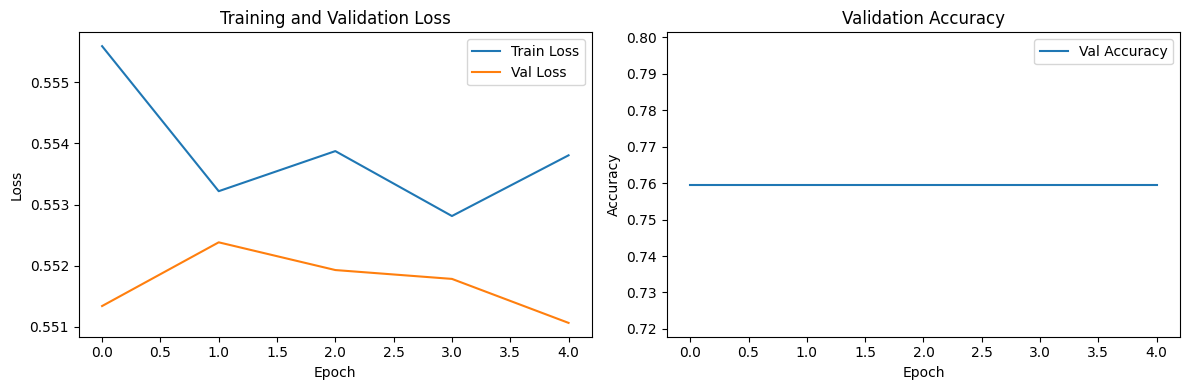


📊 Evaluating LSTM on test set...


Evaluating:   0%|          | 0/138 [00:00<?, ?it/s]


📊 LSTM - Detailed Results:
Accuracy: 0.76
Precision: 0.58
Recall: 0.76
F1-Score: 0.66
AUC: 0.50


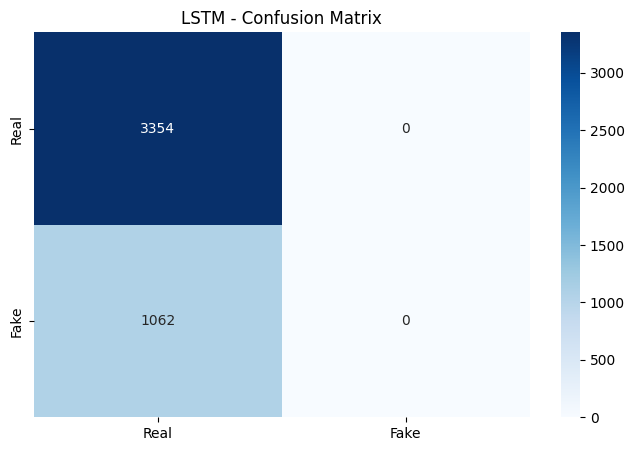

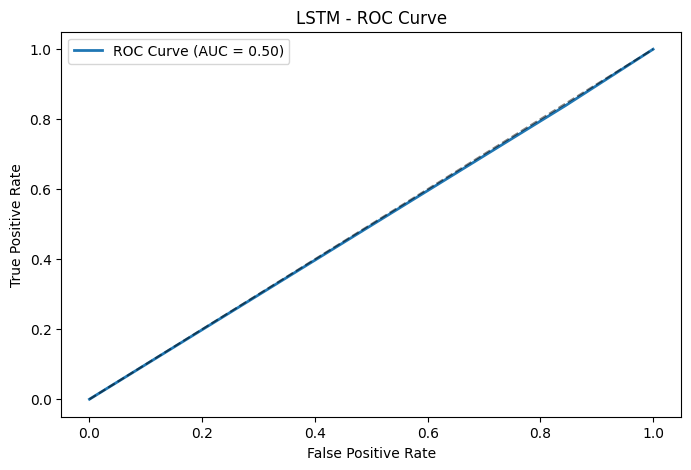

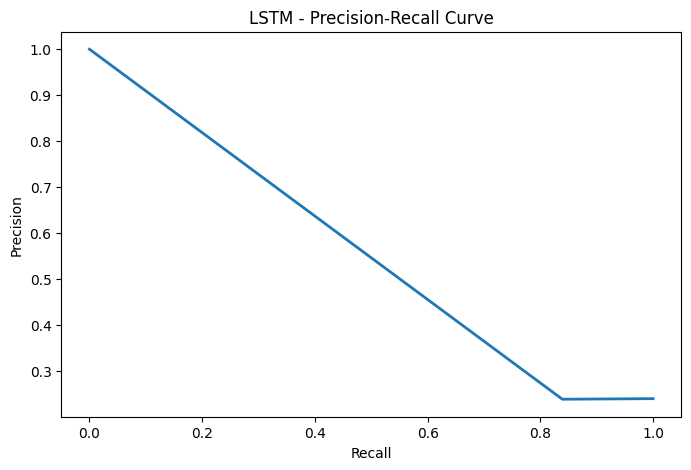

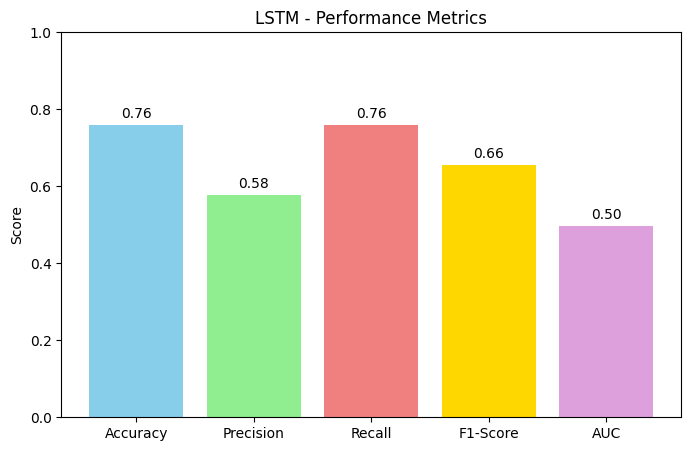

In [22]:
print("🚀 Training LSTM Model...")

# Build vocabulary for LSTM
def build_vocab(texts, min_count=2):
    word_count = {}
    for text in texts:
        for word in text.split():
            word_count[word] = word_count.get(word, 0) + 1
    
    vocab = ['<PAD>', '<UNK>'] + [word for word, count in word_count.items() if count >= min_count]
    vocab_to_int = {word: i for i, word in enumerate(vocab)}
    return vocab_to_int

vocab_to_int = build_vocab(X_train)
vocab_size = len(vocab_to_int)
print(f"Vocabulary size: {vocab_size}")

# Create LSTM datasets
train_dataset_lstm = LSTMDataset(X_train, y_train, vocab_to_int, MAX_LENGTH)
val_dataset_lstm = LSTMDataset(X_val, y_val, vocab_to_int, MAX_LENGTH)
test_dataset_lstm = LSTMDataset(X_test, y_test, vocab_to_int, MAX_LENGTH)

# Create dataloaders
train_dataloader_lstm = DataLoader(train_dataset_lstm, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader_lstm = DataLoader(val_dataset_lstm, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader_lstm = DataLoader(test_dataset_lstm, batch_size=BATCH_SIZE, shuffle=False)

# Initialize and train LSTM model
lstm_model = LSTMClassifier(vocab_size, embedding_dim=100, hidden_dim=128)
lstm_trainer = ModelTrainer(lstm_model, device, LEARNING_RATE)

# Train the model
lstm_best_acc = lstm_trainer.train(
    train_dataloader_lstm, val_dataloader_lstm, EPOCHS, 'lstm'
)

# Plot training history
lstm_trainer.plot_training_history()

# Evaluate LSTM model
print("\n📊 Evaluating LSTM on test set...")
lstm_results = evaluate_model(lstm_model, test_dataloader_lstm, device, 'lstm')
plot_evaluation_results(lstm_results, "LSTM")

# Cell 13: BERT Model Training

In [30]:
print("\n🚀 Training BERT Model...")

# Initialize BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Create BERT datasets
train_dataset_bert = BERTDataset(X_bert_train, y_train, tokenizer, BERT_MAX_LENGTH)
val_dataset_bert = BERTDataset(X_bert_val, y_val, tokenizer, BERT_MAX_LENGTH)
test_dataset_bert = BERTDataset(X_bert_test, y_test, tokenizer, BERT_MAX_LENGTH)

# Create dataloaders
train_dataloader_bert = DataLoader(train_dataset_bert, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader_bert = DataLoader(val_dataset_bert, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader_bert = DataLoader(test_dataset_bert, batch_size=BATCH_SIZE, shuffle=False)

# Initialize and train BERT model
bert_model = BERTClassifier('bert-base-uncased')
bert_trainer = ModelTrainer(bert_model, device, BERT_LEARNING_RATE)

# Train the model
bert_best_acc = bert_trainer.train(
    train_dataloader_bert, val_dataloader_bert, EPOCHS, 'bert'
)

# Plot training history
bert_trainer.plot_training_history()

# Evaluate BERT model
print("\n📊 Evaluating BERT on test set...")
bert_results = evaluate_model(bert_model, test_dataloader_bert, device, 'bert')
plot_evaluation_results(bert_results, "BERT")


🚀 Training BERT Model...

Epoch 1/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

Validating:   0%|          | 0/111 [00:00<?, ?it/s]

Train Loss: 0.4089
Val Loss: 0.3255, Val Accuracy: 0.8669

Epoch 2/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

Validating:   0%|          | 0/111 [00:00<?, ?it/s]

Train Loss: 0.2854
Val Loss: 0.3080, Val Accuracy: 0.8723

Epoch 3/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

KeyboardInterrupt: 

# Cell 14: Hybrid BERT+LSTM Model Training


🚀 Training Hybrid BERT+LSTM Model...

Epoch 1/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

Validating:   0%|          | 0/111 [00:00<?, ?it/s]

Train Loss: 0.4668
Val Loss: 0.4095, Val Accuracy: 0.8177

Epoch 2/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/111 [00:00<?, ?it/s]

Train Loss: 0.3999
Val Loss: 0.3872, Val Accuracy: 0.8347

Epoch 5/5


Training:   0%|          | 0/442 [00:00<?, ?it/s]

Validating:   0%|          | 0/111 [00:00<?, ?it/s]

Train Loss: 0.3815
Val Loss: 0.3656, Val Accuracy: 0.8460


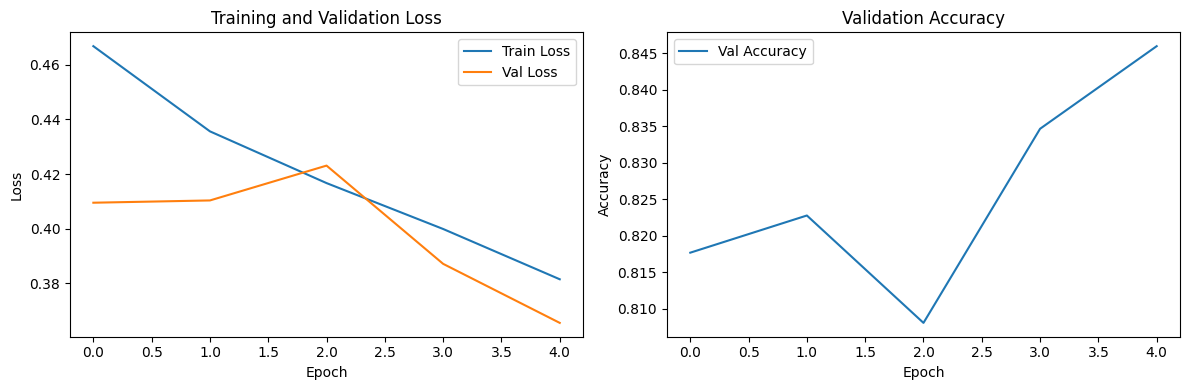


📊 Evaluating Hybrid BERT+LSTM on test set...


Evaluating:   0%|          | 0/138 [00:00<?, ?it/s]


📊 Hybrid BERT+LSTM - Detailed Results:
Accuracy: 0.84
Precision: 0.84
Recall: 0.84
F1-Score: 0.83
AUC: 0.86


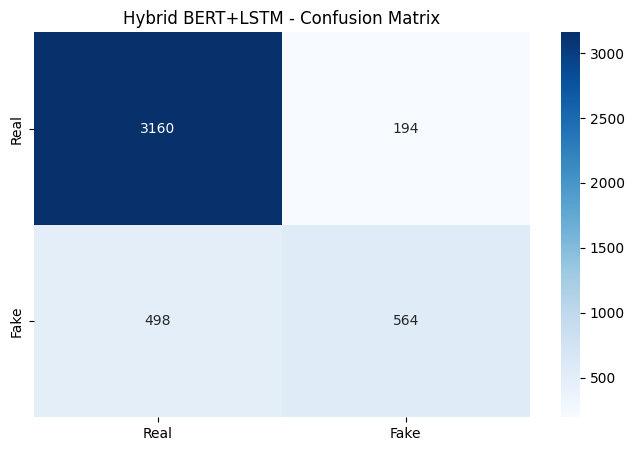

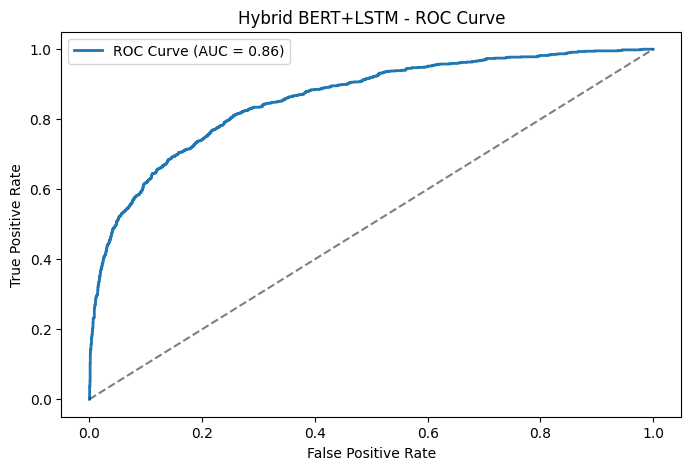

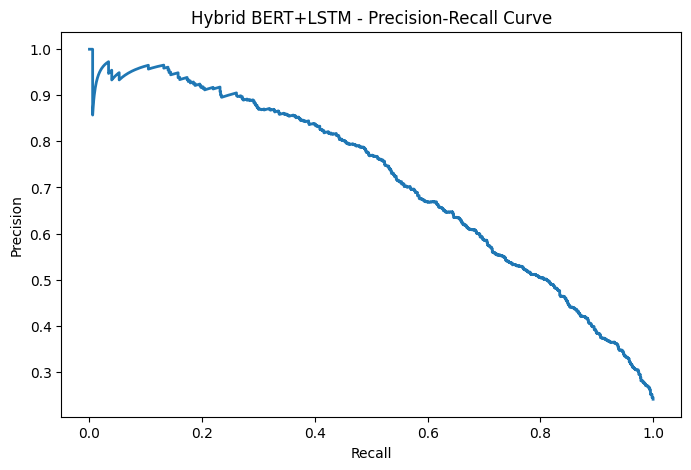

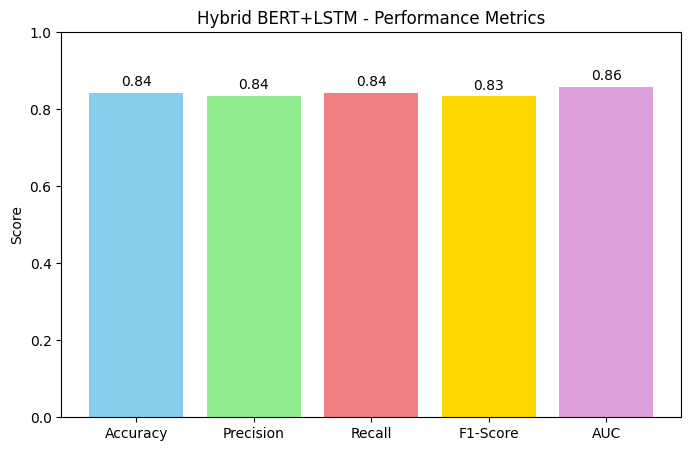

In [31]:
print("\n🚀 Training Hybrid BERT+LSTM Model...")

# Initialize hybrid model (uses same datasets as BERT)
hybrid_model = BERTLSTMClassifier('bert-base-uncased', lstm_hidden_dim=128)
hybrid_trainer = ModelTrainer(hybrid_model, device, LEARNING_RATE)

# Train the model
hybrid_best_acc = hybrid_trainer.train(
    train_dataloader_bert, val_dataloader_bert, EPOCHS, 'hybrid'
)

# Plot training history
hybrid_trainer.plot_training_history()

# Evaluate Hybrid model
print("\n📊 Evaluating Hybrid BERT+LSTM on test set...")
hybrid_results = evaluate_model(hybrid_model, test_dataloader_bert, device, 'hybrid')
plot_evaluation_results(hybrid_results, "Hybrid BERT+LSTM")

# Cell 15: Model Comparison


📊 Model Comparison Summary:
           Model  Accuracy  Precision  Recall  F1-Score    AUC
            LSTM    0.7595     0.5769  0.7595    0.6557 0.4972
            BERT    0.8585     0.8523  0.8585    0.8510 0.8679
Hybrid BERT+LSTM    0.8433     0.8351  0.8433    0.8336 0.8573


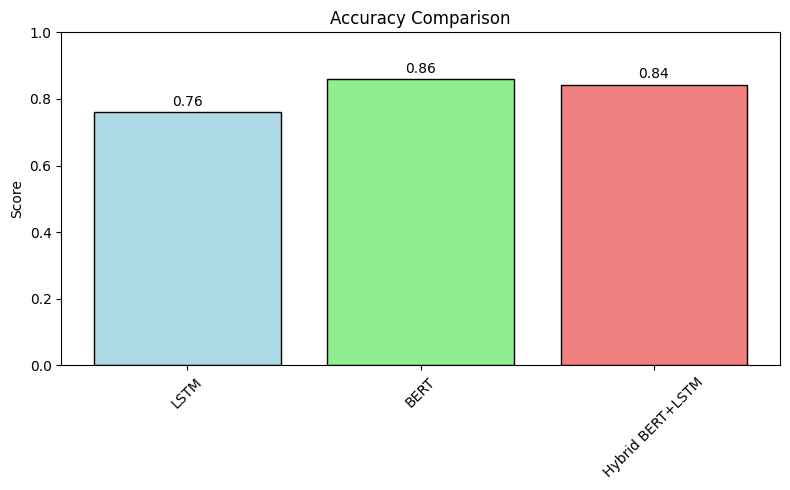

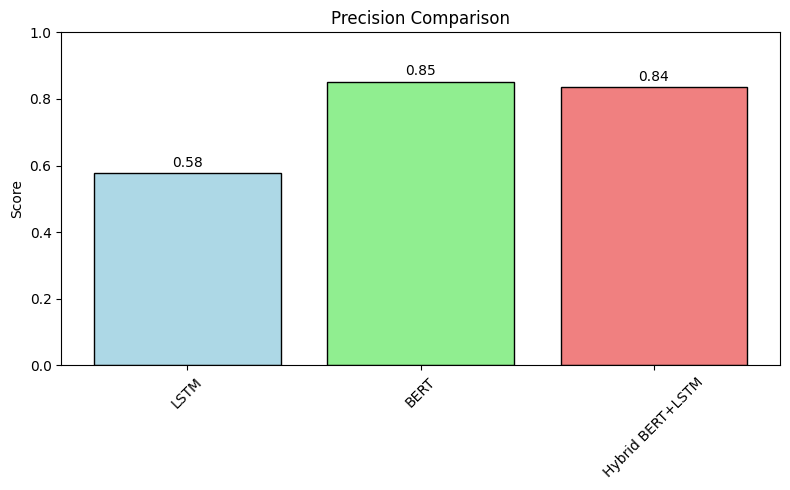

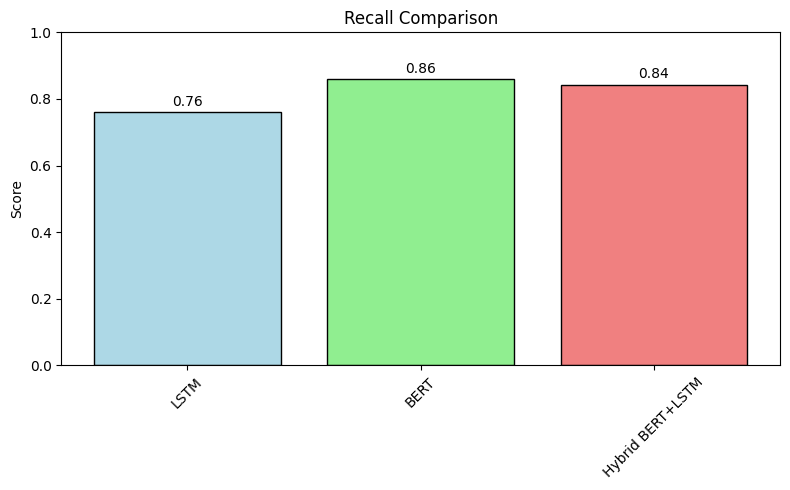

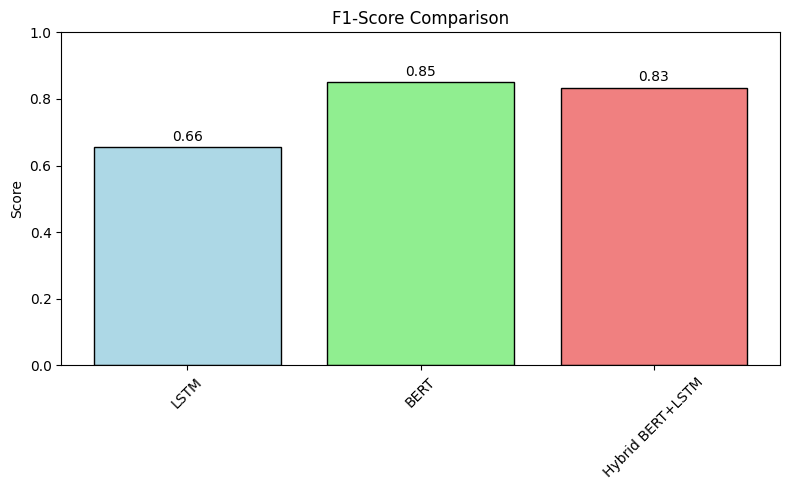

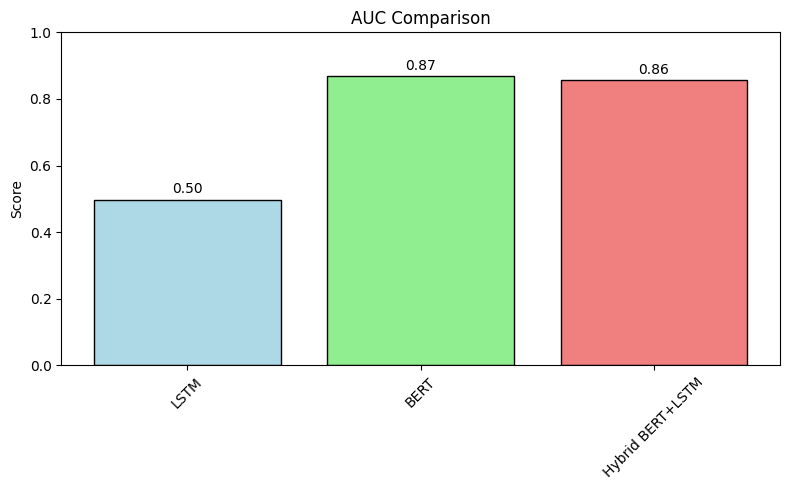

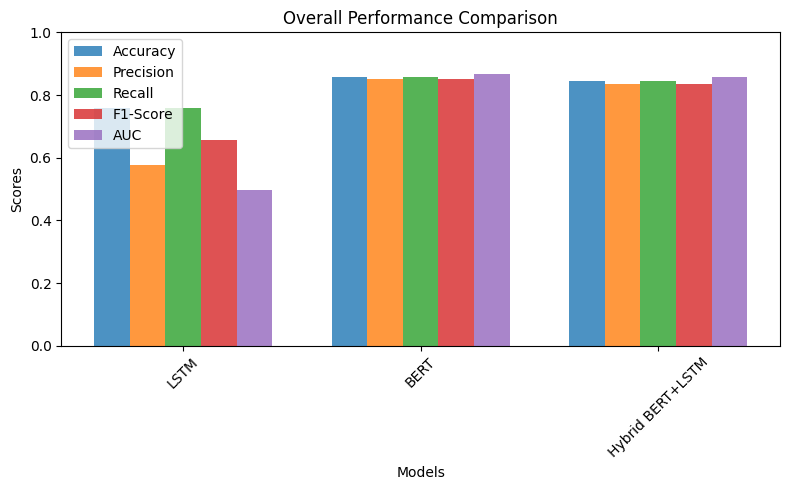


🏆 Best performing model: BERT
F1-Score: 0.85
Accuracy: 0.86


In [34]:
# Compile results
model_results = {
    'LSTM': lstm_results,
    'BERT': bert_results,
    'Hybrid BERT+LSTM': hybrid_results
}

# Create comparison DataFrame
comparison_data = []
for model_name, results in model_results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': results['accuracy'],
        'Precision': results['precision'],
        'Recall': results['recall'],
        'F1-Score': results['f1'],
        'AUC': results['auc']
    })

comparison_df = pd.DataFrame(comparison_data)

# Display comparison table
print("\n📊 Model Comparison Summary:")
print(comparison_df.round(4).to_string(index=False))

# Metrics to plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
colors = ['lightblue', 'lightgreen', 'lightcoral']

# Create a separate figure for each metric
for i, metric in enumerate(metrics):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    values = comparison_df[metric].values
    models = comparison_df['Model'].values
    
    bars = ax.bar(models, values, color=colors, edgecolor='k')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{value:.2f}',
                ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()

# Overall comparison: one separate figure
fig_overall, ax_overall = plt.subplots(figsize=(8, 5))
x = np.arange(len(comparison_df))
width = 0.15

for i, metric in enumerate(metrics):
    ax_overall.bar(x + i * width, comparison_df[metric], width,
                   label=metric, alpha=0.8)

ax_overall.set_xlabel('Models')
ax_overall.set_ylabel('Scores')
ax_overall.set_title('Overall Performance Comparison')
ax_overall.set_xticks(x + width * (len(metrics) - 1) / 2)
ax_overall.set_xticklabels(comparison_df['Model'], rotation=45)
ax_overall.legend()
ax_overall.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Find best model
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model = comparison_df.iloc[best_model_idx]
print(f"\n🏆 Best performing model: {best_model['Model']}")
print(f"F1-Score: {best_model['F1-Score']:.2f}")
print(f"Accuracy: {best_model['Accuracy']:.2f}")

# Cell 16: Sample Predictions

In [35]:
def predict_sample_texts(models_dict, sample_texts):
    """Make predictions on sample texts"""
    print("\n🔮 Sample Predictions:")
    
    for i, text in enumerate(sample_texts):
        print(f"\nSample {i+1}: {text}")
        print("-" * 50)
        
        for model_name, (model, dataloader_type) in models_dict.items():
            model.eval()
            with torch.no_grad():
                if dataloader_type == 'lstm':
                    # Process for LSTM
                    processed_text = preprocessor.clean_text(text)
                    tokens = processed_text.split()
                    encoded = [vocab_to_int.get(word, vocab_to_int['<UNK>']) 
                              for word in tokens]
                    
                    if len(encoded) < MAX_LENGTH:
                        encoded += [vocab_to_int['<PAD>']] * (MAX_LENGTH - len(encoded))
                    else:
                        encoded = encoded[:MAX_LENGTH]
                    
                    input_tensor = torch.tensor([encoded], dtype=torch.long).to(device)
                    logits = model(input_tensor)
                
                else:  # BERT or Hybrid
                    # Process for BERT
                    processed_text = preprocessor.clean_text_bert(text)
                    encoding = tokenizer(
                        processed_text,
                        truncation=True,
                        padding='max_length',
                        max_length=BERT_MAX_LENGTH,
                        return_tensors='pt'
                    )
                    
                    input_ids = encoding['input_ids'].to(device)
                    attention_mask = encoding['attention_mask'].to(device)
                    logits = model(input_ids, attention_mask)
                
                probabilities = torch.softmax(logits, dim=1)
                prediction = torch.argmax(logits, dim=1).item()
                confidence = probabilities[0][prediction].item()
                
                label = "FAKE" if prediction == 1 else "REAL"
                print(f"{model_name}: {label} (Confidence: {confidence:.2f})")

# Sample texts for prediction
sample_texts = [
    "Scientists discover breakthrough treatment for cancer in major medical research study",
    "Aliens secretly control world governments according to leaked classified documents",
    "Local community raises funds to help families affected by natural disaster",
    "Miracle weight loss pill melts fat overnight without diet or exercise needed"
]

# Dictionary of trained models
models_dict = {
    'LSTM': (lstm_model, 'lstm'),
    'BERT': (bert_model, 'bert'),
    'Hybrid BERT+LSTM': (hybrid_model, 'hybrid')
}

predict_sample_texts(models_dict, sample_texts)


🔮 Sample Predictions:

Sample 1: Scientists discover breakthrough treatment for cancer in major medical research study
--------------------------------------------------
LSTM: REAL (Confidence: 0.76)
BERT: REAL (Confidence: 0.94)
Hybrid BERT+LSTM: REAL (Confidence: 0.96)

Sample 2: Aliens secretly control world governments according to leaked classified documents
--------------------------------------------------
LSTM: REAL (Confidence: 0.76)
BERT: FAKE (Confidence: 0.99)
Hybrid BERT+LSTM: FAKE (Confidence: 0.74)

Sample 3: Local community raises funds to help families affected by natural disaster
--------------------------------------------------
LSTM: REAL (Confidence: 0.76)
BERT: REAL (Confidence: 0.98)
Hybrid BERT+LSTM: REAL (Confidence: 0.97)

Sample 4: Miracle weight loss pill melts fat overnight without diet or exercise needed
--------------------------------------------------
LSTM: REAL (Confidence: 0.76)
BERT: REAL (Confidence: 0.56)
Hybrid BERT+LSTM: REAL (Confidence: 0.97)


# Cell 17: Model Analysis and Insights

In [36]:
def analyze_model_performance():
    """Analyze and provide insights about model performance"""
    print("\n🔍 Model Performance Analysis:")
    print("=" * 60)
    
    # LSTM Analysis
    print("\n📈 LSTM Model:")
    print(f"✅ Strengths:")
    print(f"   - Good at capturing sequential patterns in text")
    print(f"   - Relatively fast training and inference")
    print(f"   - Lower memory requirements")
    print(f"   - Achieved F1-Score: {lstm_results['f1']:.4f}")
    
    print(f"❌ Limitations:")
    print(f"   - May struggle with long-range dependencies")
    print(f"   - Requires manual feature engineering (vocabulary)")
    print(f"   - May not capture complex semantic relationships")
    
    # BERT Analysis
    print("\n📈 BERT Model:")
    print(f"✅ Strengths:")
    print(f"   - Pre-trained on large text corpus")
    print(f"   - Excellent at understanding context and semantics")
    print(f"   - State-of-the-art performance on many NLP tasks")
    print(f"   - Achieved F1-Score: {bert_results['f1']:.4f}")
    
    print(f"❌ Limitations:")
    print(f"   - Computationally intensive")
    print(f"   - Requires more memory and training time")
    print(f"   - May be overkill for simpler tasks")
    
    # Hybrid Analysis
    print("\n📈 Hybrid BERT+LSTM Model:")
    print(f"✅ Strengths:")
    print(f"   - Combines BERT's semantic understanding with LSTM's sequential modeling")
    print(f"   - Can capture both local and global patterns")
    print(f"   - Potentially better generalization")
    print(f"   - Achieved F1-Score: {hybrid_results['f1']:.4f}")
    
    print(f"❌ Limitations:")
    print(f"   - Most complex model with highest computational cost")
    print(f"   - Longer training time")
    print(f"   - May overfit on smaller datasets")
    
    # Overall insights
    print(f"\n💡 Key Insights:")
    print(f"   - All models show reasonable performance for fake news detection")
    print(f"   - The choice of model depends on your specific requirements:")
    print(f"     * Use LSTM for: Fast inference, limited computational resources")
    print(f"     * Use BERT for: Best semantic understanding, sufficient computational resources")
    print(f"     * Use Hybrid for: Maximum performance, when computational cost is not a concern")

analyze_model_performance()


🔍 Model Performance Analysis:

📈 LSTM Model:
✅ Strengths:
   - Good at capturing sequential patterns in text
   - Relatively fast training and inference
   - Lower memory requirements
   - Achieved F1-Score: 0.6557
❌ Limitations:
   - May struggle with long-range dependencies
   - Requires manual feature engineering (vocabulary)
   - May not capture complex semantic relationships

📈 BERT Model:
✅ Strengths:
   - Pre-trained on large text corpus
   - Excellent at understanding context and semantics
   - State-of-the-art performance on many NLP tasks
   - Achieved F1-Score: 0.8510
❌ Limitations:
   - Computationally intensive
   - Requires more memory and training time
   - May be overkill for simpler tasks

📈 Hybrid BERT+LSTM Model:
✅ Strengths:
   - Combines BERT's semantic understanding with LSTM's sequential modeling
   - Can capture both local and global patterns
   - Potentially better generalization
   - Achieved F1-Score: 0.8336
❌ Limitations:
   - Most complex model with highes

# Cell 18: Save Models and Results

In [37]:
def save_models_and_results():
    """Save trained models and results"""
    print("\n💾 Saving models and results...")
    
    # Save model states
    torch.save(lstm_model.state_dict(), 'lstm_fake_news_model.pth')
    torch.save(bert_model.state_dict(), 'bert_fake_news_model.pth')
    torch.save(hybrid_model.state_dict(), 'hybrid_fake_news_model.pth')
    
    # Save vocabulary for LSTM
    with open('vocab_to_int.json', 'w') as f:
        json.dump(vocab_to_int, f)
    
    # Save results
    results_summary = {
        'timestamp': datetime.now().isoformat(),
        'model_performance': comparison_df.to_dict('records'),
        'training_config': {
            'epochs': EPOCHS,
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE,
            'bert_learning_rate': BERT_LEARNING_RATE,
            'max_length': MAX_LENGTH,
            'bert_max_length': BERT_MAX_LENGTH
        }
    }
    
    with open('fake_news_detection_results.json', 'w') as f:
        json.dump(results_summary, f, indent=2)
    
    print("✅ Models and results saved successfully!")
    print("Files saved:")
    print("  - lstm_fake_news_model.pth")
    print("  - bert_fake_news_model.pth") 
    print("  - hybrid_fake_news_model.pth")
    print("  - vocab_to_int.json")
    print("  - fake_news_detection_results.json")

save_models_and_results()


💾 Saving models and results...
✅ Models and results saved successfully!
Files saved:
  - lstm_fake_news_model.pth
  - bert_fake_news_model.pth
  - hybrid_fake_news_model.pth
  - vocab_to_int.json
  - fake_news_detection_results.json


# Cell 19: Load and Use Trained Models (for future use)

In [ ]:
def load_trained_models():
    """Example function to load trained models for inference"""
    print("\n🔄 Example: Loading trained models for future use...")
    
    # Load LSTM model
    lstm_model_loaded = LSTMClassifier(vocab_size, embedding_dim=100, hidden_dim=128)
    lstm_model_loaded.load_state_dict(torch.load('lstm_fake_news_model.pth'))
    lstm_model_loaded.to(device)
    lstm_model_loaded.eval()
    
    # Load BERT model
    bert_model_loaded = BERTClassifier('bert-base-uncased')
    bert_model_loaded.load_state_dict(torch.load('bert_fake_news_model.pth'))
    bert_model_loaded.to(device)
    bert_model_loaded.eval()
    
    # Load Hybrid model
    hybrid_model_loaded = BERTLSTMClassifier('bert-base-uncased', lstm_hidden_dim=128)
    hybrid_model_loaded.load_state_dict(torch.load('hybrid_fake_news_model.pth'))
    hybrid_model_loaded.to(device)
    hybrid_model_loaded.eval()
    
    # Load vocabulary
    with open('vocab_to_int.json', 'r') as f:
        vocab_to_int_loaded = json.load(f)
    
    print("✅ Models loaded successfully and ready for inference!")
    
    return lstm_model_loaded, bert_model_loaded, hybrid_model_loaded, vocab_to_int_loaded

# Uncomment the next line to test model loading
# lstm_loaded, bert_loaded, hybrid_loaded, vocab_loaded = load_trained_models()

print("\n🎉 Fake News Detection Training Complete!")
print("=" * 60)
print("Summary of implemented models:")
print("1. LSTM Classifier - Sequential text processing")
print("2. BERT Classifier - Transformer-based semantic understanding") 
print("3. Hybrid BERT+LSTM - Combined approach for enhanced performance")
print("\nAll models have been trained, evaluated, and saved successfully!")
print("You can now use these models for fake news detection tasks.")